# Additional Model - CovNeXt-Tiny

Training + evaluation notebook for an additional model: ConvNeXt-tiny. This is intentionally a work in progress: use the smoke checks while prototyping, then uncomment full training when the data path and cloud runtime are ready.

## Colab Setup

Run these when using Colab: mounts Drive, moves to repo, install dependencies from `requirements.txt`, and loads W&B auth from Colab Secrets (see README if not setup).

In [1]:
# # # # Colab only: mount Drive and move into the repo.
# from google.colab import drive

# drive.mount("/content/drive")
# %cd /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation

In [2]:
# pip install -r requirements.txt

In [3]:
# # # Colab only: load W&B API key from Colab Secrets.
# # # In Colab, add a secret named exactly WANDB_API_KEY before running this cell.
# import os
# from google.colab import userdata

# wandb_api_key = userdata.get("WANDB_API_KEY")
# if wandb_api_key:
#     os.environ["WANDB_API_KEY"] = wandb_api_key
#     print("WANDB_API_KEY loaded from Colab Secrets.")
# else:
#     print("WANDB_API_KEY was not found in Colab Secrets; W&B training will fail if enabled.")

## Local Setup

Start here when local. In Colab, run this section **after** the Colab setup above.

In [4]:
from pathlib import Path
import os
import sys

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: /home/henry/Documents/Coursework/DLE_24788/final_project/DLE-Flair-Segmentation


In [5]:
import torch
import matplotlib.pyplot as plt

from src.data import build_dataloaders, load_class_map
from src.evaluate import evaluate_class_iou
from src.models import build_model, freeze_backbone
from src.train import (
    _load_env_file,
    build_loss,
    build_optimizer,
    build_scheduler,
    finish_wandb_run,
    sync_class_config,
    train_from_config,
    train_one_epoch,
    validate_one_epoch,
)
from src.utils import get_device, load_config
from src.visualize import plot_class_iou, plot_overlay_grid, plot_prediction_comparison_grid

device = get_device()
print(f"Using device: {device}")


Using device: cuda


## Load Config

Uses model specific `yaml` to override defaults for hyperparameters, model weights, architecture setups, etc.

In [6]:
config_path = REPO_ROOT / "configs" / "convnext_tiny.yaml"
config = sync_class_config(load_config(config_path))

config

{'experiment': {'name': 'convnext_tiny', 'seed': 42, 'output_dir': 'outputs'},
 'data': {'train_csv': 'data/processed/splits/train.csv',
  'val_csv': 'data/processed/splits/val.csv',
  'test_csv': 'data/processed/splits/test.csv',
  'class_map': 'data/processed/class_map.json',
  'train_stats': 'data/processed/train_stats.json',
  'image_size': 512,
  'batch_size': 12,
  'num_workers': 0,
  'channels': [1, 2, 3, 4, 5],
  'norm_type': 'scaling',
  'norm_means': [],
  'norm_stds': [],
  'ignore_index': 255,
  'augment': {'enabled': True,
   'horizontal_flip': True,
   'vertical_flip': True,
   'random_rotate_90': True},
  'num_classes': 6},
 'model': {'name': 'convnext_tiny',
  'encoder': 'convnext_tiny',
  'pretrained': True,
  'in_channels': 5,
  'num_classes': 6},
 'training': {'max_epochs': 150,
  'min_epochs': 10,
  'warmup_frozen_epochs': 3,
  'early_stopping': {'enabled': True,
   'monitor': 'val_loss',
   'mode': 'min',
   'patience': 20,
   'min_delta': 0.0001},
  'optimizer': {

## W&B Auth Check

Local runs read `WANDB_API_KEY` from repo-root `.env`. Colab runs should load it from Colab Secrets in the setup cell above. This cell only reports whether a key is available; it never prints the key.

In [7]:
_load_env_file()
wandb_enabled = config.get("wandb", {}).get("enabled", False)
wandb_key_available = bool(os.environ.get("WANDB_API_KEY"))

print(f"W&B enabled in config: {wandb_enabled}")
print(f"WANDB_API_KEY available: {wandb_key_available}")
if wandb_enabled and not wandb_key_available:
    print("WARN: NOT LOGGED IN TO W&B.\nAdd WANDB_API_KEY to local .env or Colab Secrets before full training.")

W&B enabled in config: True
WANDB_API_KEY available: True


## Data Loading

In [8]:
train_loader, val_loader, test_loader = build_dataloaders(config["data"])
len(train_loader), len(val_loader), len(test_loader)

(17, 3, 3)

In [9]:
# sanity check dataloader output
def unpack_batch(batch):
    if isinstance(batch, dict):
        return batch["image"], batch["mask"]
    return batch

# get a single batch from the training dataloader and print shapes, dtypes, and value ranges
batch = next(iter(train_loader))
images, masks = unpack_batch(batch)

print("images", images.shape, images.dtype, images.min().item(), images.max().item())
print("masks ", masks.shape, masks.dtype, torch.unique(masks)[:20])

images torch.Size([12, 5, 512, 512]) torch.float32 0.0 1.0
masks  torch.Size([12, 512, 512]) torch.int64 tensor([0, 1, 2, 3, 4, 5])


Visualization indices: [17, 12, 2]


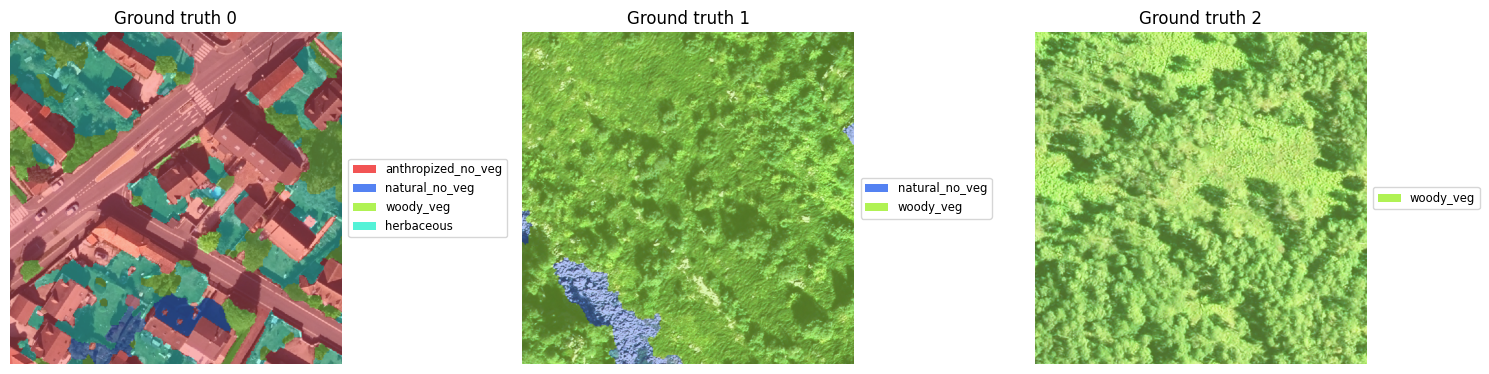

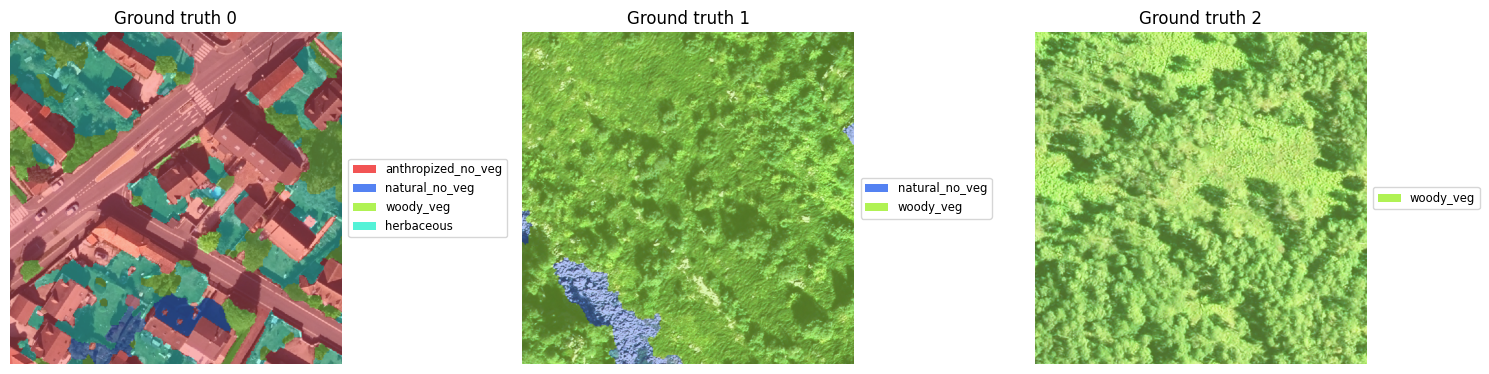

In [10]:
# load class map and get class names and ignore index for visualization
class_map = load_class_map(REPO_ROOT / config["data"]["class_map"])
class_names = class_map["class_names"]
ignore_index = config["data"].get("ignore_index", class_map.get("ignore_index", 255))

# visualize a few samples from the validation set with their ground truth masks
num_viz_items = 3
viz_generator = torch.Generator().manual_seed(config["experiment"]["seed"])
viz_indices = torch.randperm(len(val_loader.dataset), generator=viz_generator)[:num_viz_items].tolist()
viz_samples = [val_loader.dataset[index] for index in viz_indices]
viz_images = torch.stack([sample["image"] for sample in viz_samples])
viz_masks = torch.stack([sample["mask"] for sample in viz_samples])

print(f"Visualization indices: {viz_indices}")
gt_overlay_fig = plot_overlay_grid(
    viz_images,
    viz_masks,
    max_items=num_viz_items,
    title="Ground truth",
    class_names=class_names,
    ignore_index=ignore_index,
)
gt_overlay_fig


## Model, Loss, Optimizer

In [11]:
# build model and loss function
model = build_model(config["model"]).to(device)
loss_fn = build_loss(config["training"]["loss"], device)

# optionally freeze backbone layers for few warmup epochs, then unfreeze before main training loop
warmup_frozen_epochs = config["training"].get("warmup_frozen_epochs", 0)
if warmup_frozen_epochs > 0:
    freeze_backbone(model)

# build optimizer and scheduler
optimizer = build_optimizer(model, config["training"]["optimizer"])
scheduler = build_scheduler(
    optimizer,
    config["training"]["scheduler"],
    config["training"]["max_epochs"],
)

# sanity check model name
print(model.__class__.__name__)
print([group["name"] for group in optimizer.param_groups])

SegmentationModel
['head']


In [12]:
# Forward-pass smoke test
model.eval()
with torch.no_grad():
    sample_logits = model(images[:2].to(device))

print("logits", sample_logits.shape)
assert sample_logits.shape[1] == config["model"]["num_classes"]
assert sample_logits.shape[-2:] == images.shape[-2:]

logits torch.Size([2, 6, 512, 512])


## Single-Batch Verification

Optional. Uncomment when you want to verify one train step and one validation pass. This mutates model weights, so restart the kernel before real training.

In [13]:
# train_metrics = train_one_epoch(model, [batch], loss_fn, optimizer, device, epoch=1)
# val_metrics = validate_one_epoch(
#     model,
#     [batch],
#     loss_fn,
#     config["data"]["num_classes"],
#     config["data"].get("ignore_index", 255),
#     device,
# )
# train_metrics, val_metrics

## Full Training
Checkpoints will be saved under `outputs/resnet34_unet/`.

In [14]:
result = train_from_config(config_path)
result

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/henry/.netrc
wandb: Currently logged in as: hfeldhau (flair-segmentation-dle) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


train epoch 1:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

epoch 001 train_loss=1.5318 val_loss=1.3215 val_IoU=0.1885 val_loss=1.3215


train epoch 2:   0%|          | 0/17 [00:00<?, ?it/s]

...

epoch 070 train_loss=0.6251 val_loss=0.7576 val_IoU=0.6069 val_loss=0.7576


train epoch 71:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

epoch 071 train_loss=0.6323 val_loss=0.7550 val_IoU=0.5956 val_loss=0.7550
Early stopping at epoch 71. Best epoch: 51.


{'output_dir': PosixPath('outputs/convnext_tiny'),
 'best_epoch': 51,
 'best_metric': 0.6845584611097971,
 'history': [{'epoch': 1,
   'train_loss': 1.5317931736216825,
   'val_loss': 1.3215012947718303,
   'val_IoU': 0.18849308788776398,
   'head_lr': 0.001,
   'best_val_IoU': 0.18849308788776398,
   'best_val_IoU_epoch': 1},
  {'epoch': 2,
   'train_loss': 1.292707555434283,
   'val_loss': 1.2663577993710835,
   'val_IoU': 0.38386034965515137,
   'head_lr': 0.001,
   'best_val_IoU': 0.38386034965515137,
   'best_val_IoU_epoch': 2},
  {'epoch': 3,
   'train_loss': 1.224052113645217,
   'val_loss': 1.1678718129793804,
   'val_IoU': 0.3613635301589966,
   'head_lr': 0.001,
   'best_val_IoU': 0.38386034965515137,
   'best_val_IoU_epoch': 2},
  {'epoch': 4,
   'train_loss': 1.4493043703191422,
   'val_loss': 1.008404274781545,
   'val_IoU': 0.3266540467739105,
   'backbone_lr': 3e-05,
   'head_lr': 0.001,
   'best_val_IoU': 0.38386034965515137,
   'best_val_IoU_epoch': 2},
  {'epoch': 5,


## Visualize Predictions

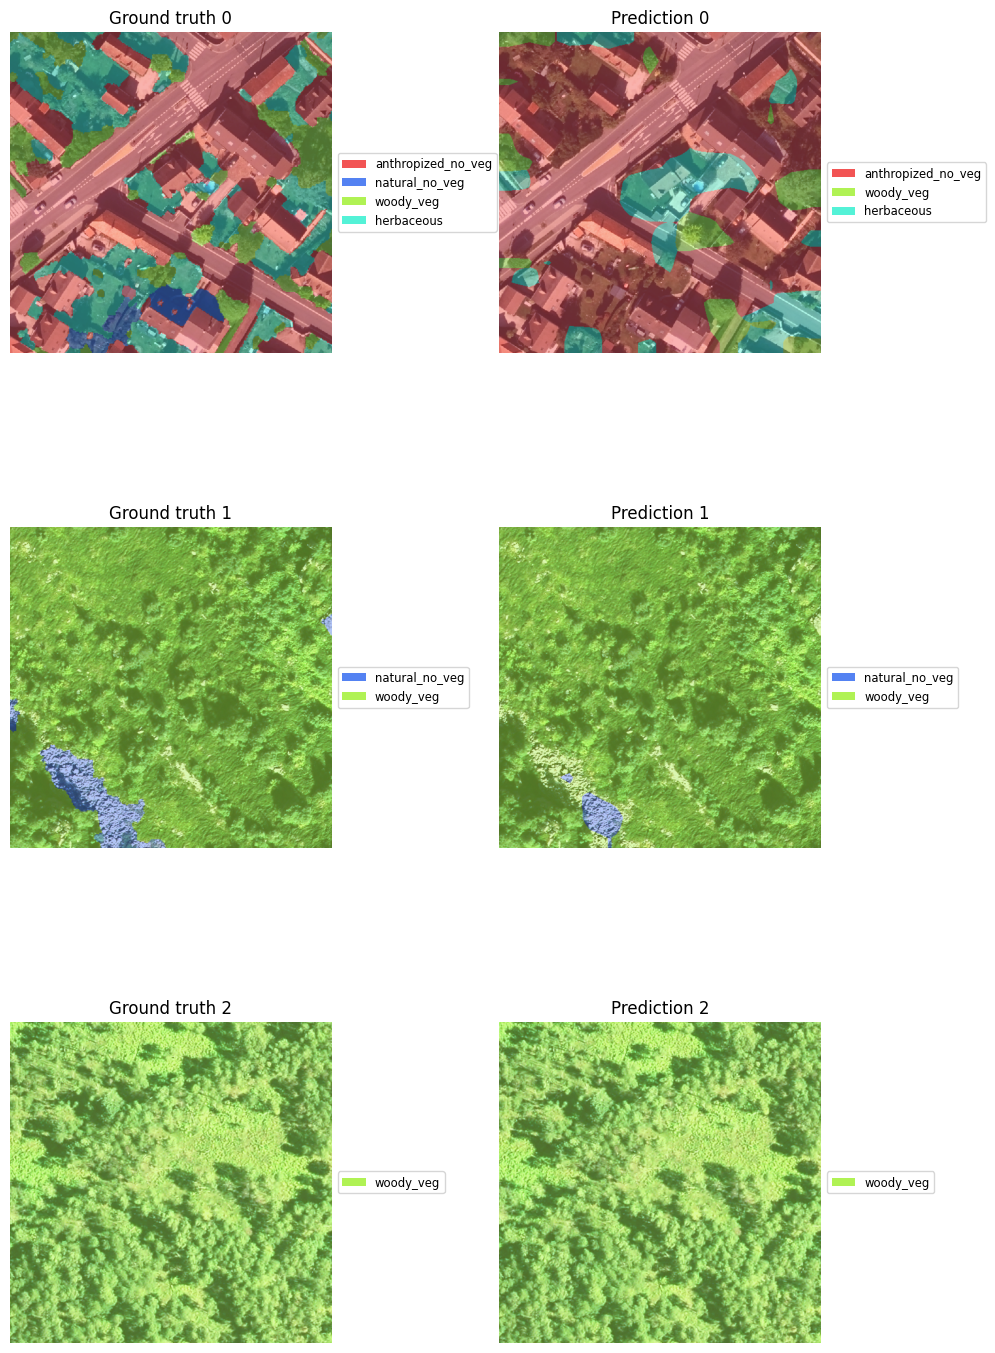

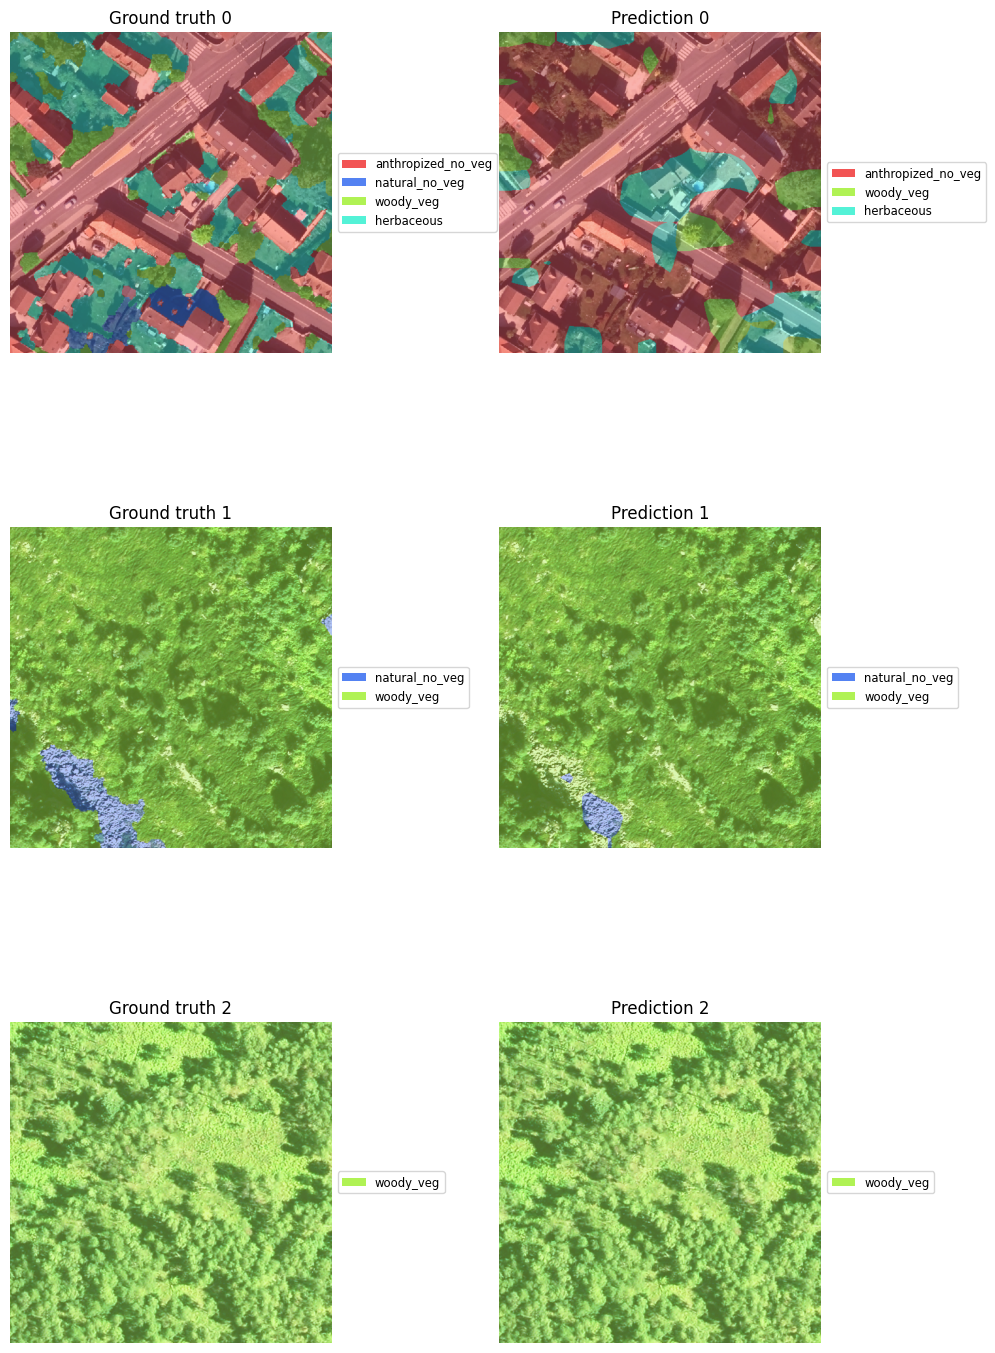

In [15]:
checkpoint_path = result["output_dir"] / "best.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {checkpoint_path}")

# load the best checkpoint for visualization
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
prediction_model = build_model(config["model"]).to(device)
prediction_model.load_state_dict(checkpoint["model_state_dict"])
prediction_model.eval()

# get predictions for visualization samples
with torch.no_grad():
    viz_logits = prediction_model(viz_images.to(device)).cpu()

# create prediction overlay figures
prediction_comparison_fig = plot_prediction_comparison_grid(
    viz_images,
    viz_masks,
    viz_logits,
    max_items=num_viz_items,
    class_names=class_names,
    ignore_index=ignore_index,
)

# log prediction overlays to W&B if enabled
if config.get("wandb", {}).get("enabled", False) and config.get("wandb", {}).get("include_images", False):
    import wandb

    step = result["history"][-1]["epoch"] if result.get("history") else None
    result["run"].log({"prediction_comparison": wandb.Image(prediction_comparison_fig)}, step=step)

# show prediction overlay figure
prediction_comparison_fig


## Best Checkpoint Class IoU

Evaluating class IoU:   0%|          | 0/3 [00:00<?, ?it/s]

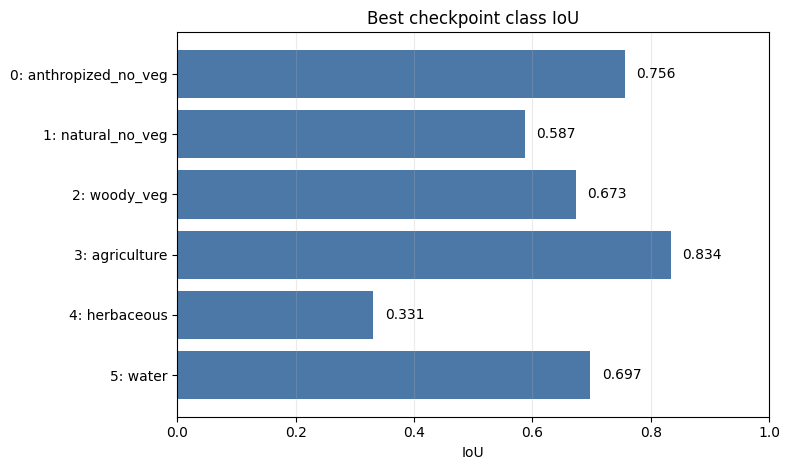

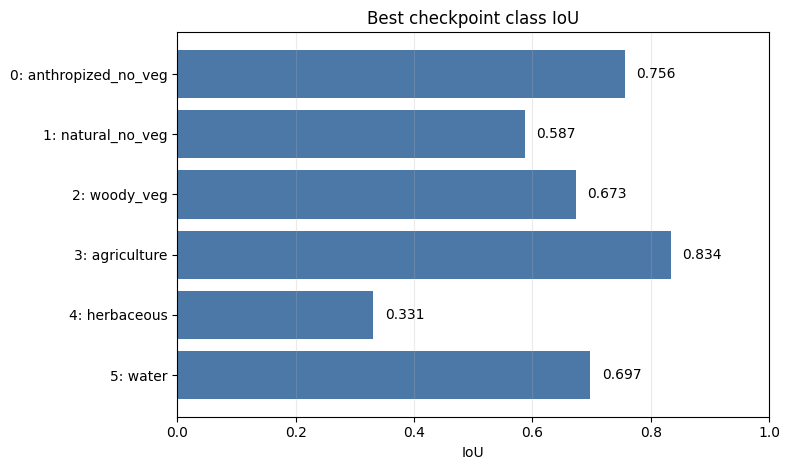

In [16]:
best_class_iou = evaluate_class_iou(
    prediction_model,
    val_loader,
    config["data"]["num_classes"],
    device,
    ignore_index=ignore_index,
    class_names=class_names,
)
best_class_iou_metrics = {
    f"best_val_iou_class_{class_id}": iou
    for class_id, iou in best_class_iou["class_iou"].items()
}
best_class_iou_fig = plot_class_iou(best_class_iou)

if result.get("run") is not None:
    import wandb

    result["run"].log(
        {
            **best_class_iou_metrics,
            "best_class_iou": wandb.Image(best_class_iou_fig),
        },
        step=result["best_epoch"],
    )

best_class_iou_fig


Closes W&B Run after all artifacts uploaded.

In [17]:
finish_wandb_run(result.get("run"))

backbone_lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_IoU,▁▄▄▄▅▇▇▇▇▇▇▇▇▇▇█████████████████████████
best_val_IoU_epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▇▇▇██████████████
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇███
head_lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▆▅▄▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_IoU,▁▄▄▅▅▆▆▆▇▇▆▇▇▇█▇▇▇▆▇██▆▇▇█▇▇█▇▇▇▇▇█▇██▇▇
val_loss,█▇▅▅▄▄▃▄▄▄▃▃▂▃▂▂▃▃▃▃▃▂▂▂▂▂▁▂▁▁▁▂▂▁▂▂▂▂▂▂
backbone_lr,3e-05
epoch,71
head_lr,0.001
